# RAG system의 각 단계별 다양한 도구 탐색

- 다양한 Document Loader, Splitter, Retriever, Reracker 도구들을 알아보자

# 1. API Key 로드

In [1]:
from dotenv import load_dotenv


load_dotenv()

True

# 2. Document Loader

## 2.1 PDFLoader

In [2]:
from langchain_community.document_loaders import PyMuPDFLoader

data_path = "../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf"
docs = PyMuPDFLoader(data_path).load()

print(type(docs))
print(len(docs))
docs[0]

<class 'list'>
28


Document(metadata={'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2022 12.0.0.4204', 'creationdate': '2025-09-09T16:43:09+09:00', 'source': '../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf', 'file_path': '../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf', 'total_pages': 28, 'format': 'PDF 1.6', 'title': '', 'author': 'dj', 'subject': '', 'keywords': '', 'moddate': '2025-09-09T16:43:09+09:00', 'trapped': '', 'modDate': "D:20250909164309+09'00'", 'creationDate': "D:20250909164309+09'00'", 'page': 0}, page_content='2025년\n9월호\n인공지능 산업의 최신 동향')

## 2.2 CSVLoader

- 문서(Document객체)당 한 행씩 로드 됨
- 한 행을 임베딩하게 되면 LLM이 잘 인지하지 못하는 경우도 많음

In [5]:
from langchain_community.document_loaders.csv_loader import CSVLoader

docs = CSVLoader("../data/titanic/train.csv").load()

print(type(docs))
print(len(docs))
docs[0]

<class 'list'>
891


Document(metadata={'source': '../data/titanic/train.csv', 'row': 0}, page_content='PassengerId: 1\nSurvived: 0\nPclass: 3\nName: Braund, Mr. Owen Harris\nSex: male\nAge: 22\nSibSp: 1\nParch: 0\nTicket: A/5 21171\nFare: 7.25\nCabin: \nEmbarked: S')

In [ ]:
print(docs[0].page_content)

PassengerId: 1
Survived: 0
Pclass: 3
Name: Braund, Mr. Owen Harris
Sex: male
Age: 22
SibSp: 1
Parch: 0
Ticket: A/5 21171
Fare: 7.25
Cabin: 
Embarked: S


In [7]:
print(docs[0].metadata)

{'source': '../data/titanic/train.csv', 'row': 0}


## 2.3 JSONLoader

### 2.3.1 파이썬에서 제공해주는 json라이브러리로 로드


In [8]:
import json

file_path = "../data/ya_review_sinla.json"

with open(file_path, encoding="utf-8") as f:
  json_data = json.load(f)

print(len(json_data))
print(json_data[0])

420
{'review': '고민하다가 조식포함으로 결정했는데 좋은 선택이었습니다. 같이간 이들도 만족스러워했어요. 조식도 좋았고 시설, 서비스, 청결도 나무랄데가 없었네요.', 'stars': 5, 'date': '2024.06.03'}


### 2.2.2 LangChain에서 제공해주는 JSONLoader

In [ ]:
# !pip install jq

In [1]:
from langchain_community.document_loaders import JSONLoader

file_path = "../data/ya_review_sinla.json"

loader = JSONLoader(
  file_path=file_path,
  jq_schema=".",  # 접근해서 로드할 key(필드) 지정 (".": 모든 필드에 접근 )
  text_content = False  # 접근할 데이터가 str인지 확인하는 옵션(default: True)
)

docs = loader.load()
docs[0]


Document(metadata={'source': '/Users/leejungyeon/Desktop/sesac/data/ya_review_sinla.json', 'seq_num': 1}, page_content='[{"review": "\\uace0\\ubbfc\\ud558\\ub2e4\\uac00 \\uc870\\uc2dd\\ud3ec\\ud568\\uc73c\\ub85c \\uacb0\\uc815\\ud588\\ub294\\ub370 \\uc88b\\uc740 \\uc120\\ud0dd\\uc774\\uc5c8\\uc2b5\\ub2c8\\ub2e4. \\uac19\\uc774\\uac04 \\uc774\\ub4e4\\ub3c4 \\ub9cc\\uc871\\uc2a4\\ub7ec\\uc6cc\\ud588\\uc5b4\\uc694. \\uc870\\uc2dd\\ub3c4 \\uc88b\\uc558\\uace0 \\uc2dc\\uc124, \\uc11c\\ube44\\uc2a4, \\uccad\\uacb0\\ub3c4 \\ub098\\ubb34\\ub784\\ub370\\uac00 \\uc5c6\\uc5c8\\ub124\\uc694.", "stars": 5, "date": "2024.06.03"}, {"review": "\\ucee4\\ud53c\\ucfe0\\ud3f0\\ub3c4 \\ubc1b\\uc558\\uad6c \\uae68\\ub057\\ud558\\uace0 \\uad50\\ud68c\\ubdf0\\ub3c4 \\uc774\\ubee4\\uc5b4\\uc694!!!", "stars": 5, "date": "2022.11.20"}, {"review": "\\uc78a\\uc744\\uc218\\uc5c6\\ub294 \\ucd94\\uc5b5\\uc744 \\ub0a8\\uacbc\\uc5b4\\uc694 \\ub108\\ubb34\\ub108\\ubb34 \\uc88b\\uc558\\uc5b4\\uc694\\r\\n\\uc5ec\\uc790\\u

# 3. 문서 분할

## 3.1 CharacterTextSplitter

- `\n\n` 기준으로 텍스트를 분할 (즉, 문단을 기준으로 분할됨)
    - 문장을 기준으로 분할하고 싶을 경우: `\n`사용
- 문자 수로 청크 크기 결정 
- 즉, 
    - 지정된 chunk_size 이내에서 `\n\n`를 찾은 후 `\n\n`를 발견하면 `\n\n`를 기준으로 자름  
    - 예를 들어 chunk_size가 100인데 93글자 쯤에서 `\n\n`를 발견하면 그 부분을 기준으로 chunk를 자름 
    - 근데 만약 chunk_size를 넘겨서 `\n\n`를 발견하여 자를 경우 자르긴 자르지만 경고문자가 뜸 

In [4]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import CharacterTextSplitter

# 1. 문서 로드
data_path = "../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf"
docs = PyMuPDFLoader(data_path).load()

# 2. 문서 분할(split) = splitter 객체 정의 및 분할 진행
splitter = CharacterTextSplitter(
  separator="\n", # 분할 기준 -> 현재 문서는 문서 자체가 \n\n을 기준으로 분할 되어있기 때문에 split 전후의 청크 개수에 차이가 없음
  chunk_size=600,
  chunk_overlap=100
)

docs_split = splitter.split_documents(docs)

print(len(docs))
print(len(docs_split))
docs_split[0]


28
86


Document(metadata={'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2022 12.0.0.4204', 'creationdate': '2025-09-09T16:43:09+09:00', 'source': '../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf', 'file_path': '../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf', 'total_pages': 28, 'format': 'PDF 1.6', 'title': '', 'author': 'dj', 'subject': '', 'keywords': '', 'moddate': '2025-09-09T16:43:09+09:00', 'trapped': '', 'modDate': "D:20250909164309+09'00'", 'creationDate': "D:20250909164309+09'00'", 'page': 0}, page_content='2025년\n9월호\n인공지능 산업의 최신 동향')

## 3.2 RecursiveCharacterTextSplitter

- 문자 분할 목록을 매개변수로 받아 동작(텍스트를 분할) 
    - 기본 문자 분할 목록: `["\n\n", "\n", " ", ""]`
    - 단락 -> 문장 -> 단어 순으로 재귀적으로 분할
    - 이는 해당 단위가 의미적으로 가장 강하게 연관된 텍스트 조각으로 간주되기 때문

In [3]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 1. 문서 로드
data_path = "../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf"
docs = PyMuPDFLoader(data_path).load()

# 2. 문서 분할(split) = splitter 객체 정의 및 분할 진행
splitter = RecursiveCharacterTextSplitter(
  chunk_size=600,
  chunk_overlap=100
)

docs_split = splitter.split_documents(docs)

print(len(docs))
print(len(docs_split))
docs_split[0]


28
86


Document(metadata={'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2022 12.0.0.4204', 'creationdate': '2025-09-09T16:43:09+09:00', 'source': '../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf', 'file_path': '../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf', 'total_pages': 28, 'format': 'PDF 1.6', 'title': '', 'author': 'dj', 'subject': '', 'keywords': '', 'moddate': '2025-09-09T16:43:09+09:00', 'trapped': '', 'modDate': "D:20250909164309+09'00'", 'creationDate': "D:20250909164309+09'00'", 'page': 0}, page_content='2025년\n9월호\n인공지능 산업의 최신 동향')

# 4. Embedding & VectorStore 정의

In [6]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

# 1. 문서 로드
data_path = "../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf"
docs = PyMuPDFLoader(data_path).load()

# 2. 문서 분할(split) = splitter 객체 정의 및 분할 진행
splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=100)
docs_split = splitter.split_documents(docs)

# 3. embedding 객체 정의
embedding = OpenAIEmbeddings(model="text-embedding-ada-002")

# 4. vectorstore 정의 및 벡터 저장
vectorstore=Chroma.from_documents(
  documents=docs_split,
  embedding=embedding,
  persist_directory="./Chroma",
  collection_name="sesac3"
)



Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


# 5. Retriever

## 5.1 as_retriever()

- vectorstore에서 기본적으로 제공해주는 검색기 사용
- vectorstore: 제일 처음 컬렉션을 생성할 때만 아래의 코드를 실행 -> 그 이후에는 주석처리 해놔야 문서가 중복적으로 저장되지 않음


In [9]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

# 1. 문서 로드
data_path = "../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf"
docs = PyMuPDFLoader(data_path).load()

# 2. 문서 분할(split) = splitter 객체 정의 및 분할 진행
splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=100)
docs_split = splitter.split_documents(docs)

# 3. embedding 객체 정의
embedding = OpenAIEmbeddings(model="text-embedding-ada-002")

# 4.1 vectorstore 정의 및 벡터 저장
# vectorstore: 제일 처음 컬렉션을 생성할 때만 아래의 코드를 실행 -> 그 이후에는 주석처리 해놔야 문서가 중복적으로 저장되지 않음
vectorstore=Chroma.from_documents(
  documents=docs_split,
  embedding=embedding,
  persist_directory="./Chroma",
  collection_name="sesac3"
)

print(vectorstore._collection.count)

# 4.2 이미 생성해놓은 vectorstore의 collection 불러오기
vectorstore = Chroma(
  embedding_function = embedding,  # 현재 불러올 collection에 적용한 embedding 모델과 동일한 모델을 전달해야됨
  persist_directory="./Chroma", # 항상 경로 잘 확인하기
  collection_name = "sesac3"
)

print(vectorstore.collection.count())

# # 5. retriever 객체 생성 & 가장 유사한 청크 검색
# retriever = vectorstore.as_retriever()
# results = retriever.invoke("AI 글로벌 거버넌스 행동계획을 발표한 나라는 어느 나라야?")

# print(results[0])

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


<bound method Collection.count of Collection(name=sesac3)>


AttributeError: 'Chroma' object has no attribute 'collection'

In [8]:
# 현재 collection의 모든 chunk 제거 -> 제거 후에는 항상 주석 처리 하기
vectorstore.delete(ids=vectorstore.get()["ids"])
print(vectorstore._collection.count())  # 제거 후 chunk 개수 확인

Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionDeleteEvent: capture() takes 1 positional argument but 3 were given


0


## 5.2 LLM 압축기

- 대량의 문서를 단순히 조회하는 게 아니라, 문서의 중요한 정보만 압축해 제공
- 문서 압축(Compression)과 검색(Retriever)을 결합한 방식
- 문맥에 따라 중요하지 않은 부분을 제거하고 관련된 정보만 압축해 제공
    - 어떤 질문이 들어올지 모르기 때문에 질문과 관련성이 높은 내용이 관련 없는 내용이 포함된 문서에 묻힐 수 있는 것을 방지
- 모델이 후처리 할 데이터의 양이 줄어들며, 답변 생성 품질이 높아짐 
- 처리 과정 (from. https://drive.google.com/uc?id=1CtNgWODXZudxAWSRiWgSGEoTNrUFT98v)
    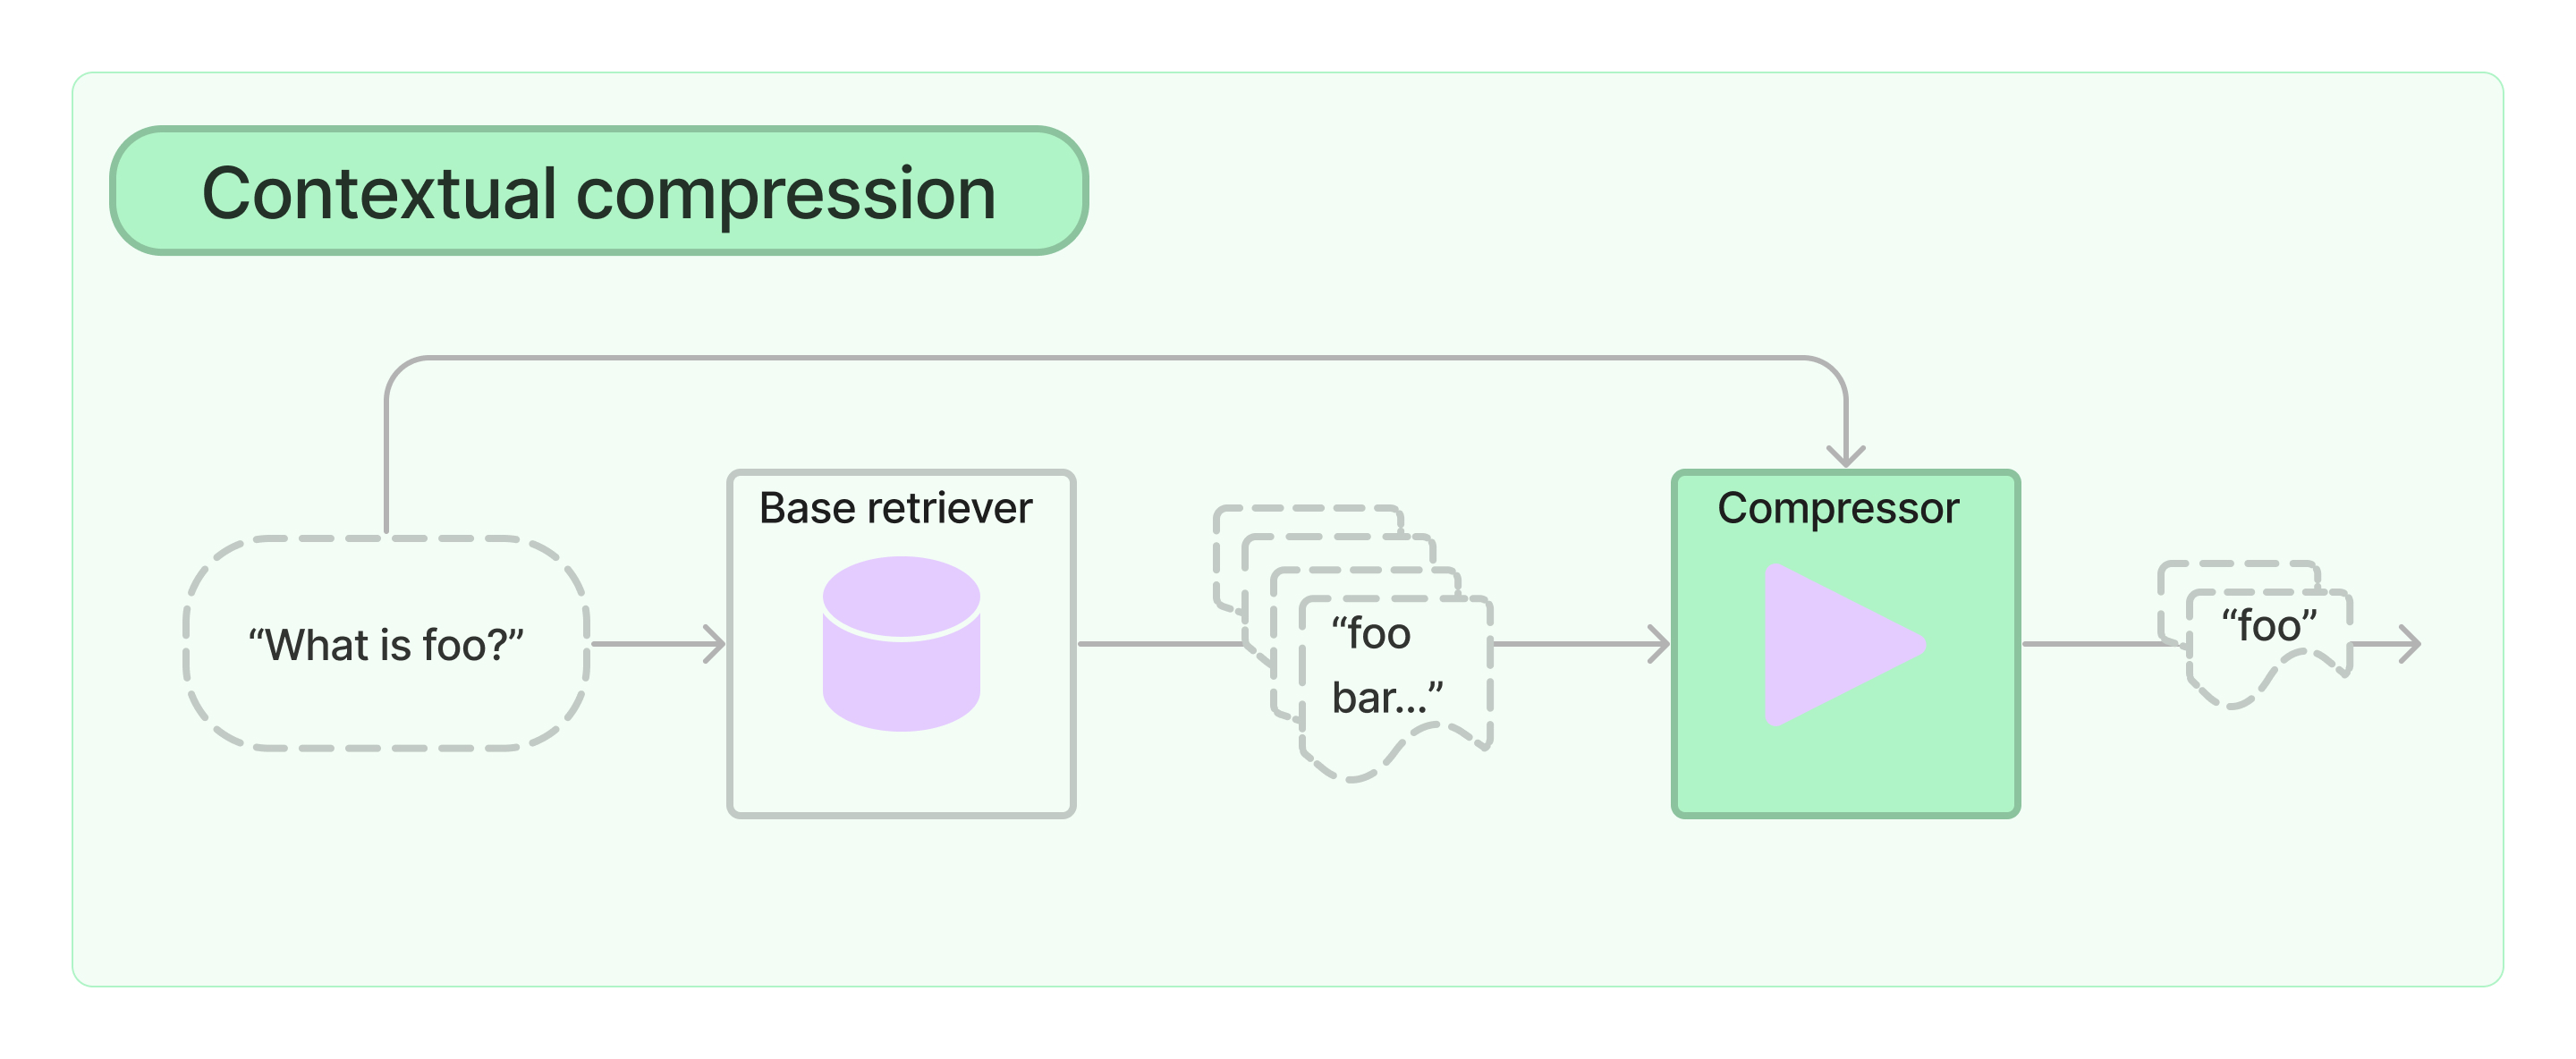
    - 검색 결과를 compressor(압축기)에 넣어서 가장 관련된 내용만 뽑아줌

In [ ]:
# !pip install llmlingua

In [10]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain.retrievers import ContextualCompressionRetriever
from langchain_openai import ChatOpenAI


# 1. 문서 로드
data_path = "../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf"
docs = PyMuPDFLoader(data_path).load()

# 2. 문서 분할(split) = splitter 객체 정의 및 분할 진행
splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=100)
docs_split = splitter.split_documents(docs)

# 3. embedding 객체 정의
embedding = OpenAIEmbeddings(model="text-embedding-ada-002")

# 4. vectorstore 정의 및 벡터 저장
vectorstore=Chroma.from_documents(
  documents=docs_split,
  embedding=embedding,
  persist_directory="./Chroma",
  collection_name="sesac3"
)

# 5. 압축기 생성(retriever + compressor)
retriever = vectorstore.as_retriever()
compressor = LLMChainExtractor.from_llm(ChatOpenAI(model="gpt-4o-mini"))
compression_retriever = ContextualCompressionRetriever(
  base_retriever=retriever,
  base_compressor=compressor
)

# 6. 검색 실행
compressed_docs=compression_retriever.invoke("AI 글로벌 거버넌스 행동계획을 발표한 나라는 어느 나라야?")

print(len(compressed_docs))
print()

for page in compressed_docs:
  print(page.metadata["page"])
  print(page.page_content)
  print("\n", "-"*20)

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


4

4
∙AI 글로벌 거버넌스 행동계획’ 발표  
n 중국 정부는 이번 행사에서 글로벌 AI 개발과 거버넌스에서 아래와 같은 조치를 통해 세계 각국의 
참여와 협력을 촉구하는 ‘AI 글로벌 거버넌스 행동계획’도 발표

 --------------------
4
£ 세계 각국의 공동 참여를 촉구하는 ‘AI 글로벌 거버넌스 행동계획’ 발표  
n 중국 정부는 이번 행사에서 글로벌 AI 개발과 거버넌스에서 아래와 같은 조치를 통해 세계 각국의 
참여와 협력을 촉구하는 ‘AI 글로벌 거버넌스 행동계획’도 발표

 --------------------
4
£ 세계 각국의 공동 참여를 촉구하는 ‘AI 글로벌 거버넌스 행동계획’ 발표  
n 중국 정부는 이번 행사에서 글로벌 AI 개발과 거버넌스에서 아래와 같은 조치를 통해 세계 각국의 
참여와 협력을 촉구하는 ‘AI 글로벌 거버넌스 행동계획’도 발표

 --------------------
4
n 중국 정부는 AI 기회의 공동 포착과 혁신 발전, AI를 통한 산업 발전, 표준과 규범 합의, AI 역량 강화를 위한 국제협력을 골자로 하는 ‘AI 글로벌 거버넌스 행동계획’도 발표

 --------------------


# 6. Reranker

- reranking을 지원하는 cohere라이브러리 (cohere사에서 지원)
- 한 달에 1000건으로 API사용 제한이 있음 
- Cohere의 API를 활용해 최소한의 코드로 구현할 수 있음
- 한국어 성능도 나쁘지 않다고 평가 됨
- 홈페이지: https://dashboard.cohere.com/api-keys
    - cohere 홈페이지의 dashboard에서 API Key 발급 (COHERE_API_KEY환경변수 이름으로 저장)
- **CohereRerank**클래스
    - langchain과 cohere를 연동해 reranking을 지원하는 클래스 

In [19]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain.retrievers import ContextualCompressionRetriever
from langchain_openai import ChatOpenAI
from langchain_cohere import CohereRerank


# 1. 문서 로드
data_path = "../data/SPRi AI Brief_9월호_산업동향_0909_F.pdf"
docs = PyMuPDFLoader(data_path).load()

# 2. 문서 분할(split) = splitter 객체 정의 및 분할 진행
splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=100)
docs_split = splitter.split_documents(docs)

# 3. embedding 객체 정의
embedding = OpenAIEmbeddings(model="text-embedding-ada-002")

# 4. vectorstore 정의 및 벡터 저장
vectorstore=Chroma.from_documents(
  documents=docs_split,
  embedding=embedding,
  persist_directory="./Chroma",
  collection_name="sesac3"
)

# 5. retriever & reranker 생성
retriever = vectorstore.as_retriever()
reranker = CohereRerank(
  model="rerank-v3.5",
  top_n=3 # 최종적으로 가장 관련성이 높은 3개의 결과만 반환
)


# 6. 압축기 생성
compression_retriever = ContextualCompressionRetriever(
  base_retriever=retriever,
  base_compressor=reranker
)

# 7. 검색 실행
compressed_docs=compression_retriever.invoke("AI 글로벌 거버넌스 행동계획을 발표한 나라는 어느 나라야?")

print(len(compressed_docs))
print()

for page in compressed_docs:
  print(page.metadata["page"])
  print(page.page_content)
  print("\n", "-"*20)

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


3

4
* 주로 남반구나 북반구의 저위도에 위치한 120여개 개발도상국을 지칭
∙AI 기술의 돌파구를 마련하기 위한 협력에 더욱 집중하여 기초 과학기술 R&D 협력을 심화하고 기술과 
인재 교류를 강화하는 한편, 글로벌 거버넌스에 더욱 집중하기 위한 세계 AI 협력기구 설립을 제안
£ 세계 각국의 공동 참여를 촉구하는 ‘AI 글로벌 거버넌스 행동계획’ 발표  
n 중국 정부는 이번 행사에서 글로벌 AI 개발과 거버넌스에서 아래와 같은 조치를 통해 세계 각국의 
참여와 협력을 촉구하는 ‘AI 글로벌 거버넌스 행동계획’도 발표
∙(AI 기회 공동 포착과 혁신 발전) 다양한 국제 과학기술 협력 플랫폼의 구축과 혁신 친화적 정책 환경 조성, 
정책과 규제 조율 강화, “AI 플러스” 개방형 응용 시나리오의 심도 있는 탐색을 추진
∙(AI를 통한 산업 발전) AI를 통해 제조, 소비, 유통, 의료, 교육, 농업 등 다양한 분야의 역량을 강화하고 
지능형 인프라 구축과 공유, 국경 간 AI 응용 협력, 모범사례 공유 등으로 실물경제의 발전을 촉진
∙(디지털 인프라 구축 가속화) 전 세계 청정에너지, 지능형 컴퓨팅 자원, 데이터센터와 같은 인프라 구축을

 --------------------
4
* 주로 남반구나 북반구의 저위도에 위치한 120여개 개발도상국을 지칭
∙AI 기술의 돌파구를 마련하기 위한 협력에 더욱 집중하여 기초 과학기술 R&D 협력을 심화하고 기술과 
인재 교류를 강화하는 한편, 글로벌 거버넌스에 더욱 집중하기 위한 세계 AI 협력기구 설립을 제안
£ 세계 각국의 공동 참여를 촉구하는 ‘AI 글로벌 거버넌스 행동계획’ 발표  
n 중국 정부는 이번 행사에서 글로벌 AI 개발과 거버넌스에서 아래와 같은 조치를 통해 세계 각국의 
참여와 협력을 촉구하는 ‘AI 글로벌 거버넌스 행동계획’도 발표
∙(AI 기회 공동 포착과 혁신 발전) 다양한 국제 과학기술 협력 플랫폼의 구축과 혁신 친화적 정책 환경 조성, 
정책과 규제 조율 강화, “AI 플러스” 개방형 

# 7. 죄종 응답

In [20]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
system_prompt = "당신은 유능한 AI assistant입니다. 친절하게 답변해주세요~"
user_prompt = """\
사용자 질의를 보고 context를 참고하여 답변해주세요.
--사용자 질의--
{question}
--context--
{context}
"""
final_prompt = ChatPromptTemplate([
    ("system", system_prompt),
    ("user", user_prompt)
])
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
chain = final_prompt | model | StrOutputParser()

context_text = "\n".join(chunk.page_content for chunk in results)
response = chain.invoke({"question": "AI 글로벌 거버넌스 행동계획을 발표한 나라는 어느나라야?", "context": compressed_docs[0].page_content})
print(response)

AI 글로벌 거버넌스 행동계획을 발표한 나라는 **중국**입니다. 중국 정부는 이번 행사에서 글로벌 AI 개발과 거버넌스를 위한 다양한 조치를 통해 세계 각국의 참여와 협력을 촉구하는 행동계획을 발표했습니다.
